# Classification

Is the second most popular supervised learning task.

# MNIST

In this project we will be using **MNIST** dataset, that contains 70 000 images of handwritten digits. Each picture labeled with integer it represents.

It's often called the "Hello World!" of Machine Learning.

**SKlearn** provides simple fetching of popular datasets:

In [24]:
from sklearn.datasets import fetch_openml
import numpy as np

mnist = fetch_openml("mnist_784", version=1, as_frame=False) # https://stackoverflow.com/questions/67544370/keyerror-while-fetching-mnist-data
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

> `fetch_openml()` by default returns DataFrame on 12.05.2025, set `as_frame=False` to get NumPy array.

- DESCR key describing the dataset
- A data key containing an array with one row per instance and one column per
feature
- A target key containing an array with the labels

In [25]:
X: np.ndarray = mnist["data"]
y: np.ndarray = mnist["target"]
print(X.shape, y.shape)

(70000, 784) (70000,)


Wow! Each integer has 784 features, that's because each picture contains of $ 28 \times 28 $ pixels. And each feature value represents intensity, from 0 *(white)* to 255 *(black)*

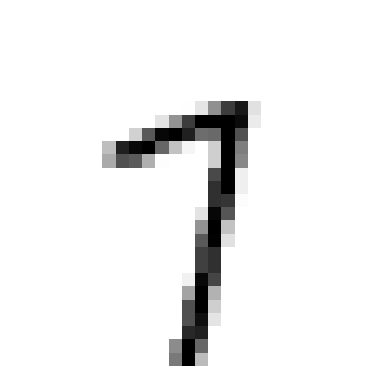

In [26]:
import matplotlib.pyplot as plt

some_digit = X[42]
some_digit_image = some_digit.reshape(28, 28)

some_digit_label = y[42]

plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()


To be able to display pixels, you need to reshape vector to a $ 28 \times 28 $ array and display in **MatPlotLib Imshow** that allows to create pictures from 2d arrays.

Looks like 1 or 7. Let's check it's label:

In [29]:
print(some_digit_label)
print(type(some_digit_label))

7
<class 'str'>


That's 7! But label type is string, let's parce it to integer.

In [30]:
y.astype(np.uint8)

array([5, 0, 4, ..., 4, 5, 6], shape=(70000,))

But firstly, let's create test and train sets. The **MNIST** dataset is already shuffled and easily can be split into 60k length train and 10k length test sets.

In [ ]:
X_train, X_test = X[:60_000], X[60_000:]
y_train, y_test = y[:60_000], y[60_000:]

# Training a Binary Classifier